In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["MUJOCO_GL"] = "egl"

In [2]:
import numpy as np

In [3]:
import argparse
import pathlib
import sys

import numpy as np
import torch
#from omegaconf import OmegaConf

import sys
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append("/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch")
import dreamer as dreamer_main
import models as dreamer_models
import tools as dreamer_tools
import ruamel.yaml as yaml

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
def _parse_dreamer_config(configs_path, config_names, overrides):
    configs = yaml.safe_load(pathlib.Path(configs_path).read_text())

    def recursive_update(base, update):
        for key, value in update.items():
            if isinstance(value, dict) and key in base:
                recursive_update(base[key], value)
            else:
                base[key] = value

    name_list = ["defaults", *config_names] if config_names else ["defaults"]
    defaults = {}
    for name in name_list:
        recursive_update(defaults, configs[name])

    overrides_map = {}
    for item in overrides:
        if item.startswith("--"):
            item = item[2:]
        if "=" in item:
            key, value = item.split("=", 1)
            if key not in defaults:
                raise KeyError(f"Unknown config key '{key}' in override.")
            cast = dreamer_tools.args_type(defaults[key])
            overrides_map[key] = cast(value)
        else:
            if item not in defaults:
                raise KeyError(f"Unknown config key '{item}' in override.")
            overrides_map[item] = True

    merged = {**defaults, **overrides_map}
    return argparse.Namespace(**merged)

## Create environment

In [5]:
# Real Dreamer obs_batch from DMC cartpole_swingup (vision + proprio)
import numpy as np
import torch

from envs import dmc
import envs.wrappers as wrappers

# Create env (matches Dreamer DMC defaults)
env = dmc.DeepMindControl("cartpole_swingup",
                          action_repeat=2,
                          size=(64, 64),
                          seed=0)
env = wrappers.NormalizeActions(env)

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/dreamerv3/lib/python3.11/site

In [6]:
def load_dreamer_world_model(
        configs_path="/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/configs.yaml",
        config_names=["dmc_vision"],
        overrides=["task=dmc_cartpole_swingup"],
        ckpt_path='/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/logdir/dmc_cartpole_swingup_pixel/latest.pt',
        env=None,
        device='cuda:0'):
    cfg = _parse_dreamer_config(
        configs_path,
        config_names,
        overrides,
    )
    cfg.num_actions = 1
    assert env is not None, "You must provide an environment with a valid observation_space."
    wm = dreamer_models.WorldModel(env.observation_space,
                                   None,
                                   step=0,
                                   config=cfg).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    agent_state = ckpt.get("agent_state_dict", ckpt)

    # Handle torch.compile() prefix - strip '_orig_mod.' from keys
    agent_state = {
        k.replace('_orig_mod.', ''): v for k, v in agent_state.items()
    }

    wm_state = {
        k[len("_wm."):]: v
        for k, v in agent_state.items()
        if k.startswith("_wm.")
    }
    wm.load_state_dict(wm_state, strict=True)
    wm.eval()
    return wm, cfg


# Example usage (you must provide 'env'):
wm, cfg = load_dreamer_world_model(env=env)

Encoder CNN shapes: {'image': (64, 64, 3)}
Encoder MLP shapes: {}
Decoder CNN shapes: {'image': (64, 64, 3)}
Decoder MLP shapes: {}


/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/tools.py:747: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/scratch/slurm_tmpdir/job_1609775/ipykernel_837423/4137543794.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend yo

Optimizer model_opt has 15685251 variables.


## Rollouts

In [7]:
# Latent rollout + reconstruction from a start observation and action sequence
import torch


def latent_rollout_and_reconstruction(wm,
                                      obs_batch,
                                      actions,
                                      steps=5,
                                      use_soft_stoch=False,
                                      deterministic=False,
                                      verbose=False,
                                      is_rgb=True):
    """
    Perform latent rollout and reconstruction from a start observation and action sequence.
    
    Args:
        wm: The world model object.
        obs_batch: Batch of observations.
        actions: Action sequence tensor of shape (B, T, action_dim).
        steps: Number of rollout steps. Default: 5
        use_soft_stoch: If True, use softmax probabilities for 'stoch' in discrete latent. Default: False
        deterministic: If True, use mode sampling in img_step. Default: False

    Returns:
        feats: Tensor of shape (B, steps+1, feat_dim)
        recons: Dict of tensors, each of shape (B, steps+1, ...)
    """
    data = wm.preprocess(obs_batch)
    embed = wm.encoder(data)
    # post, _ = wm.dynamics.observe(embed=embed,
    #                               action=actions[:, 0],
    #                               is_first=torch.zeros((1, 1)).to('cuda'),
    #                               sample=False)

    print(embed.shape)
    post, _ = wm.dynamics.obs_step(prev_state=None,
                                   prev_action=actions[:, 0],
                                   embed=embed[:, 0],
                                   is_first=torch.zeros((1, 1)).to('cuda'),
                                   sample=False)
    state = post

    feats = []
    recons = {}

    def _feat_and_recon(cur_state):
        if use_soft_stoch and "logit" in cur_state:
            probs = torch.softmax(cur_state["logit"], dim=-1)
            cur_state = {**cur_state, "stoch": probs}
        feat = wm.dynamics.get_feat(cur_state)
        if is_rgb:
            feat = feat.unsqueeze(1)

        dists = wm.heads["decoder"](feat)
        if is_rgb:
            recon = {k: v.mode().squeeze(1) for k, v in dists.items()}
        else:
            recon = {k: v.mode() for k, v in dists.items()}
        return feat, recon

    feat0, recon0 = _feat_and_recon(state)
    feats.append(feat0)
    for k, v in recon0.items():
        recons.setdefault(k, []).append(v)

    for t in range(1, steps):
        old_deter = state["deter"].clone()
        state = wm.dynamics.img_step(state,
                                     actions[:, t],
                                     sample=not deterministic)
        if verbose:
            print(
                f"Step {t}: deter changed by {(state['deter'] - old_deter).abs().mean().item()}"
            )
        feat_t, recon_t = _feat_and_recon(state)
        feats.append(feat_t)
        for k, v in recon_t.items():
            recons.setdefault(k, []).append(v)

    feats = torch.stack(feats, dim=1)  # (B, steps, feat_dim)
    recons = {k: torch.stack(v, dim=1) for k, v in recons.items()}

    return feats, recons


def get_feats_all(wm, obs_batch):

    with torch.no_grad():
        data = wm.preprocess(obs_batch)
        embed = wm.encoder(data)
        post, _ = wm.dynamics.observe(embed, data["action"], data["is_first"])
        feats = wm.dynamics.get_feat(post)  # (B, T, feat_dim)

        probs = torch.softmax(post["logit"], dim=-1)  # (B,T,stoch,discrete)
        state_soft = {**post, "stoch": probs}
        feat_soft = wm.dynamics.get_feat(state_soft)
    return feats, feat_soft


#print(feats.shape, feat_soft.shape)

In [8]:
import pickle

with open(
        "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/data_passive.pkl",
        "rb") as f:
    data_passive = pickle.load(f)

In [9]:
data_passive.keys()

dict_keys(['obs_states', 'obs_pixels'])

In [10]:
obs_pixels = data_passive['obs_pixels']
obs_states = data_passive['obs_states']
obs_pixels.shape, obs_states.shape


((22500, 64, 64, 3), (22500, 5))

In [11]:
obs_pixels_list = np.array_split(obs_pixels, obs_pixels.shape[0] // 500)
obs_states_list = np.array_split(obs_states, obs_states.shape[0] // 500)

obs_pixels_list[0].shape, obs_states_list[0].shape


((500, 64, 64, 3), (500, 5))

In [12]:
# obs_autonomous_stacked = np.concatenate(
#     [obs_autonomous[key] for key in obs_autonomous.keys()], axis=0)
# obs_autonomous_stacked.shape

In [38]:
steps_to_run = 500
obs_autonomous_episodic = {}

xx = []
for ob_states, ob_pixels in zip(obs_states_list, obs_pixels_list):
    episode = {}
    episode['position'] = ob_states[:steps_to_run, :3][None, ...]
    episode['velocity'] = ob_states[:steps_to_run, 3:][None, ...]
    episode['action'] = np.zeros(steps_to_run).reshape(-1, 1)[None, ...]
    episode['is_first'] = np.zeros((1, steps_to_run, 1))
    episode['is_first'][:, 0, :] = 1  # Set only timestep 0 to is_first=1
    episode['is_terminal'] = np.zeros(steps_to_run).reshape(-1, 1)[None, ...]
    episode['image'] = ob_pixels[:steps_to_run, ...][None, ...]
    initial_position = ob_states[0, 0]
    initial_angle = np.round(
        np.degrees(np.arctan2(ob_states[0, 2], ob_states[0, 1])) % 360)
    key = (initial_position, initial_angle)
    obs_autonomous_episodic[key] = episode
    xx.append(initial_angle)

# Optionally, to make a batch structure (collate episodes together for batch usage):
obs_autonomous_batch_stacked = {
    'position':
        np.concatenate(
            [ep['position'] for ep in obs_autonomous_episodic.values()],
            axis=1),  # (num_episodes, episode_length, 3)
    'velocity':
        np.concatenate(
            [ep['velocity'] for ep in obs_autonomous_episodic.values()],
            axis=1),  # (num_episodes, episode_length, ...)
    'action':
        np.concatenate(
            [ep['action'] for ep in obs_autonomous_episodic.values()],
            axis=1),  # (num_episodes, episode_length, 3)
    'is_first':
        np.concatenate(
            [ep['is_first'] for ep in obs_autonomous_episodic.values()],
            axis=1),  # (num_episodes, episode_length, 3)
    'is_terminal':
        np.concatenate(
            [ep['is_terminal'] for ep in obs_autonomous_episodic.values()],
            axis=1),  # (num_episodes, episode_length, 3)
    'image':
        np.concatenate([ep['image'] for ep in obs_autonomous_episodic.values()],
                       axis=1)  # (num_episodes, episode_length, 64, 64, 3)
}


In [40]:
-36 % 360

324

In [33]:
obs_autonomous_episodic.keys()

dict_keys([(-1.5, 2063.0), (-1.5, 4125.0), (-1.5, 6188.0), (-1.5, 8251.0), (-1.5, 10313.0), (-1.5, -8251.0), (-1.5, -6188.0), (-1.5, -4125.0), (-1.5, -2063.0), (-1.0, 2063.0), (-1.0, 4125.0), (-1.0, 6188.0), (-1.0, 8251.0), (-1.0, 10313.0), (-1.0, -8251.0), (-1.0, -6188.0), (-1.0, -4125.0), (-1.0, -2063.0), (0.0, 2063.0), (0.0, 4125.0), (0.0, 6188.0), (0.0, 8251.0), (0.0, 10313.0), (0.0, -8251.0), (0.0, -6188.0), (0.0, -4125.0), (0.0, -2063.0), (1.0, 2063.0), (1.0, 4125.0), (1.0, 6188.0), (1.0, 8251.0), (1.0, 10313.0), (1.0, -8251.0), (1.0, -6188.0), (1.0, -4125.0), (1.0, -2063.0), (1.5, 2063.0), (1.5, 4125.0), (1.5, 6188.0), (1.5, 8251.0), (1.5, 10313.0), (1.5, -8251.0), (1.5, -6188.0), (1.5, -4125.0), (1.5, -2063.0)])

In [14]:
#ep_to_analyze['image'] = ep_to_analyze['image'].transpose(0, 1, 4, 2, 3)

In [15]:
ep_to_analyze = obs_autonomous_episodic[(-1, 36.)]
feats, recons = latent_rollout_and_reconstruction(wm,
                                                  ep_to_analyze,
                                                  torch.zeros(
                                                      (1, 200, 1)).to('cuda'),
                                                  steps=50,
                                                  use_soft_stoch=True,
                                                  deterministic=True)

torch.Size([1, 500, 4096])


In [16]:
#Example usage:
feats_old, feat_soft = get_feats_all(wm, obs_autonomous_batch_stacked)
feat_soft = feat_soft.squeeze().detach().cpu().numpy()
feat_soft.shape

(22500, 1536)

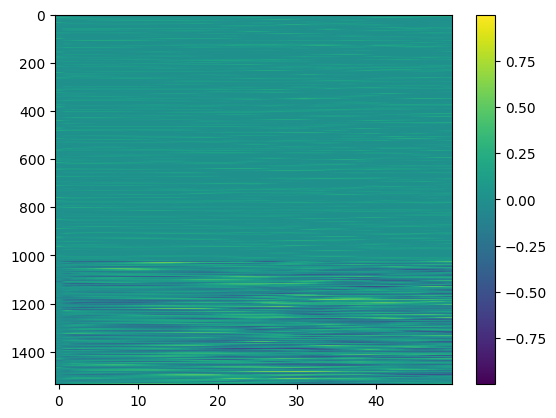

In [17]:
ff = feats.squeeze().detach().cpu().numpy()

plt.imshow(ff.T, aspect='auto')
plt.colorbar()

## Fit linear probe

In [30]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# # Collect all latents and observations
# all_latents = []
# all_observations = []

# # Concatenate all |episodes
# X = feat_soft
# y = obs_autonomous_stacked
# print(X.shape, y.shape)
# # Split into train and test
# X_train, X_test, y_train, y_test = train_test_split(X,
#                                                     y,
#                                                     test_size=0.2,
#                                                     random_state=42)

# # Fit linear probe for each observation dimension
# linear_probe = LinearRegression()
# linear_probe.fit(X_train, y_train)
# y_pred = linear_probe.predict(X_test)
# r2 = r2_score(y_test, y_pred)

# print(f"R²: {np.mean(r2):.4f}")

## Analysis of the dynamics

In [25]:
from tqdm import tqdm
from itertools import product
from sklearn.metrics import r2_score

In [28]:
obs_autonomous_episodic.keys()

dict_keys([(-1.5, 36.0), (-1.5, 72.0), (-1.5, 108.0), (-1.5, 144.0), (-1.5, 180.0), (-1.5, -144.0), (-1.5, -108.0), (-1.5, -72.0), (-1.5, -36.0), (-1.0, 36.0), (-1.0, 72.0), (-1.0, 108.0), (-1.0, 144.0), (-1.0, 180.0), (-1.0, -144.0), (-1.0, -108.0), (-1.0, -72.0), (-1.0, -36.0), (0.0, 36.0), (0.0, 72.0), (0.0, 108.0), (0.0, 144.0), (0.0, 180.0), (0.0, -144.0), (0.0, -108.0), (0.0, -72.0), (0.0, -36.0), (1.0, 36.0), (1.0, 72.0), (1.0, 108.0), (1.0, 144.0), (1.0, 180.0), (1.0, -144.0), (1.0, -108.0), (1.0, -72.0), (1.0, -36.0), (1.5, 36.0), (1.5, 72.0), (1.5, 108.0), (1.5, 144.0), (1.5, 180.0), (1.5, -144.0), (1.5, -108.0), (1.5, -72.0), (1.5, -36.0)])

In [29]:
initial_angles

array([ 36.,  72., 108., 144., 180., 216., 252., 288., 324.])

In [41]:
intital_positions = [0]
initial_angles = np.linspace(0, 360, 11)[1:-1]
steps_to_run = 500

results = {}
for initial_position, initial_angle in tqdm(
        product(intital_positions, initial_angles)):
    obs_true_batch = obs_autonomous_episodic[(initial_position, initial_angle)]
    obs_true = np.concatenate([
        obs_true_batch['position'].squeeze(),
        obs_true_batch['velocity'].squeeze()
    ],
                              axis=1)
    _, z_true = get_feats_all(wm, obs_true_batch)
    z_true = z_true.detach().cpu().numpy().squeeze()

    z_predicted, obs_reconstructed = latent_rollout_and_reconstruction(
        wm,
        obs_true_batch,
        torch.zeros((1, steps_to_run, 1)).to('cuda'),
        steps=steps_to_run,
        use_soft_stoch=True,
        deterministic=True)

    #obs_predicted = np.concatenate([
    #    obs_reconstructed['position'].detach().cpu().numpy().squeeze(),
    #    obs_reconstructed['velocity'].detach().cpu().numpy().squeeze()
    #],
    #                               axis=1)

    z_predicted = z_predicted.detach().cpu().numpy().squeeze()
    #obs_predicted = linear_probe.predict(z_predicted)

    dict_results_steps = {}
    #for k in list(range(1, 10 + 1)) + [20] + [30] + [40] + [50]:
    # z_predicted_steps, obs_true_steps = run_dynamics_model_in_steps(
    #     agent, env, initial_state, n_steps=steps_to_run, k=k)
    # obs_predicted_steps = linear_probe.predict(z_predicted_steps)
    # dict_results_steps[f'z_predicted_steps_{k}'] = z_predicted_steps
    # #dict_results_steps[f'obs_true_steps_{k}'] = obs_true_steps
    # dict_results_steps[f'obs_predicted_steps_{k}'] = obs_predicted_steps

    errors_latent = (abs(z_true - z_predicted)).mean(1)
    # errors_physical = (abs(obs_true - obs_predicted)).mean(1)
    # error_physical_per_dim = [
    #     (abs(obs_true[:, i] - obs_predicted[:, i])).mean() for i in range(5)
    # ]
    error_latent_per_dim = [
        (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
    ]
    # r2_physical = r2_score(obs_true, obs_predicted)
    # r2_physical_per_dim = [
    #     r2_score(obs_true[:, i], obs_predicted[:, i]) for i in range(5)
    # ]
    r2_latent = r2_score(z_true, z_predicted)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
    ]

    r2_latent_per_time = [
        r2_score(z_true[t, :], z_predicted[t, :]) for t in range(steps_to_run)
    ]

    r2_latent_per_time_stoch = [
        r2_score(z_true[t, :1024], z_predicted[t, :1024])
        for t in range(steps_to_run)
    ]

    r2_latent_per_time_deter = [
        r2_score(z_true[t, 1024:], z_predicted[t, 1024:])
        for t in range(steps_to_run)
    ]

    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
    variance_obs_true_per_dim = np.var(obs_true, axis=0)
    #variance_obs_predicted_per_dim = np.var(obs_predicted, axis=0)

    results[(initial_position, initial_angle)] = {
        'obs_true': obs_true,
        #'obs_predicted': obs_predicted,
        'obs_reconstructed': obs_reconstructed,
        'z_true': z_true,
        'z_predicted': z_predicted,
        **dict_results_steps,
        'errors_latent': errors_latent,
        #'errors_physical': errors_physical,
        #'error_physical_per_dim': error_physical_per_dim,
        'error_latent_per_dim': error_latent_per_dim,
        #'r2_physical': r2_physical,
        #'r2_physical_per_dim': r2_physical_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'r2_latent_per_time': r2_latent_per_time,
        'r2_latent_per_time_stoch': r2_latent_per_time_stoch,
        'r2_latent_per_time_deter': r2_latent_per_time_deter,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
        'variance_obs_true_per_dim': variance_obs_true_per_dim,
        #'variance_obs_predicted_per_dim': variance_obs_predicted_per_dim,
    }

0it [00:00, ?it/s]

torch.Size([1, 500, 4096])


1it [00:02,  2.08s/it]

torch.Size([1, 500, 4096])


2it [00:04,  2.05s/it]

...

7it [00:14,  2.09s/it]

torch.Size([1, 500, 4096])


8it [00:16,  2.09s/it]

torch.Size([1, 500, 4096])


9it [00:18,  2.08s/it]


In [46]:
z_predicted.shape

(500, 1536)

## Latent R2 per time

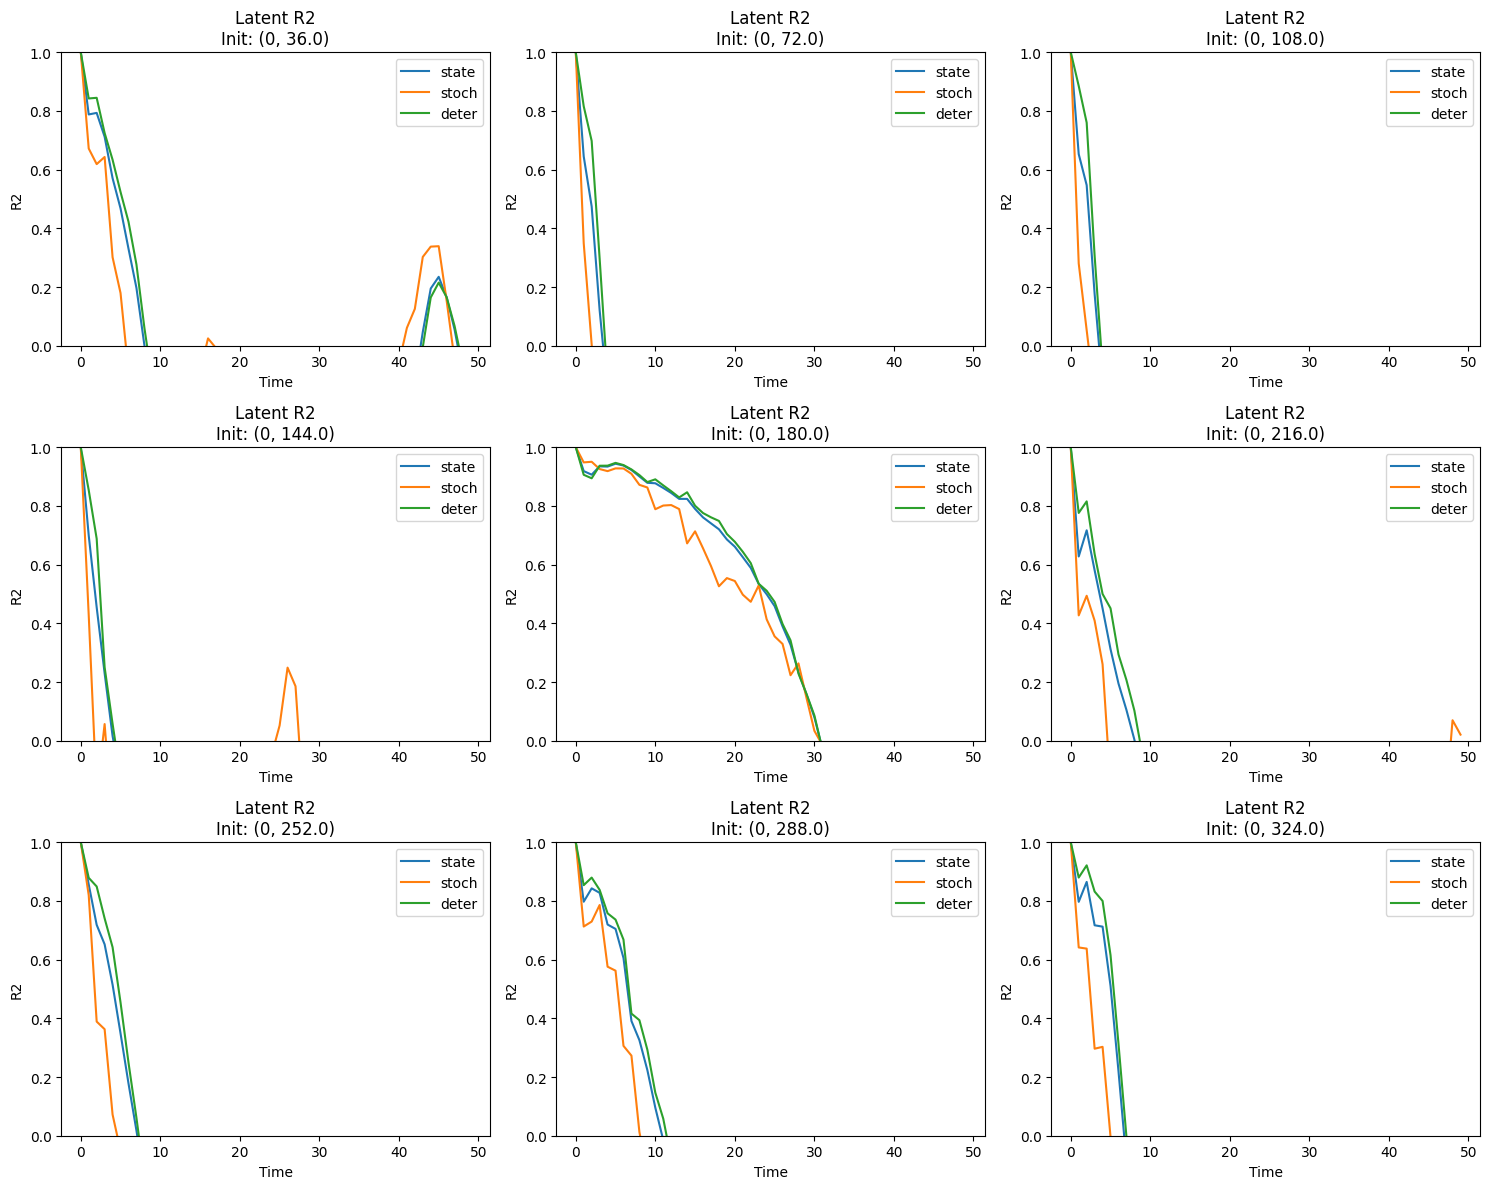

In [44]:
# Plot all initial condition R2 curves, 3 plots per row in a grid
initial_conditions = sorted(results.keys())
n_conds = len(initial_conditions)
ncols = 3
nrows = (n_conds + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, cond in enumerate(initial_conditions):
    ax = axes[i]
    ax.plot(results[cond]['r2_latent_per_time'][:50], label='state')
    ax.plot(results[cond]['r2_latent_per_time_stoch'][:50], label='stoch')
    ax.plot(results[cond]['r2_latent_per_time_deter'][:50], label='deter')
    ax.set_title(f'Latent R2\nInit: {cond}')
    ax.set_xlabel('Time')
    ax.set_ylabel('R2')
    ax.set_ylim(0, 1)
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [51]:
import pickle

with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/results_dynamics/results_dreamer_dynamics_pixel.pkl',
        'wb') as f:
    pickle.dump(results, f)


In [48]:
results.keys()

dict_keys([(0, 36.0), (0, 72.0), (0, 108.0), (0, 144.0), (0, 180.0), (0, 216.0), (0, 252.0), (0, 288.0), (0, 324.0)])

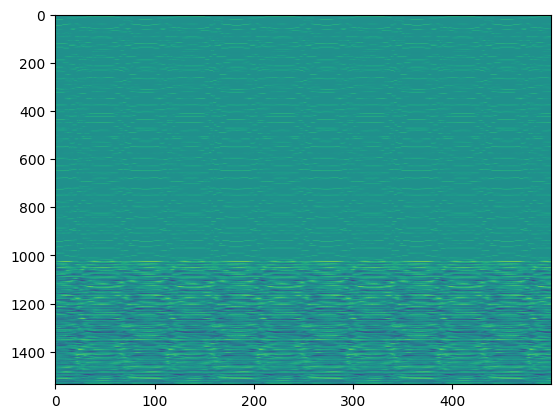

In [49]:
plt.imshow(results[(0, 108.0)]['z_true'].T, aspect='auto')